In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\RUTIK BHAMARE\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)


Libraries imported successfully!


In [14]:
import os

print("Files in current folder:")

for file in os.listdir():
    print(file)

Files in current folder:
Flipkart_Mobiles.csv


In [12]:
import pandas as pd

In [15]:
df = pd.read_csv("Flipkart_Mobiles.csv")
print(df.shape)

(3114, 8)


In [16]:
df.head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990,17990
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990,15990


In [17]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 3114
Columns: 8


In [18]:
print(df.columns.tolist())

['Brand', 'Model', 'Color', 'Memory', 'Storage', 'Rating', 'Selling Price', 'Original Price']


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           3114 non-null   str    
 1   Model           3114 non-null   str    
 2   Color           3114 non-null   str    
 3   Memory          3071 non-null   str    
 4   Storage         3075 non-null   str    
 5   Rating          2970 non-null   float64
 6   Selling Price   3114 non-null   int64  
 7   Original Price  3114 non-null   int64  
dtypes: float64(1), int64(2), str(5)
memory usage: 194.8 KB


In [20]:
missing = df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
Memory      43
Storage     39
Rating     144
dtype: int64


In [21]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 108


In [22]:
df = df.drop_duplicates()

print("Duplicates removed.")
print("New shape:", df.shape)

Duplicates removed.
New shape: (3006, 8)


In [24]:
print(df.columns.tolist())

['Brand', 'Model', 'Color', 'Memory', 'Storage', 'Rating', 'Selling Price', 'Original Price']


In [25]:
print(df.columns)

Index(['Brand', 'Model', 'Color', 'Memory', 'Storage', 'Rating',
       'Selling Price', 'Original Price'],
      dtype='str')


In [27]:
df['Original Price']

0       15990
1       15990
2       17990
3       17990
4       15990
        ...  
3109    25990
3110    28449
3111    31489
3112    22989
3113    22595
Name: Original Price, Length: 3006, dtype: int64

In [28]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(df.columns.tolist())

['brand', 'model', 'color', 'memory', 'storage', 'rating', 'selling_price', 'original_price']


In [30]:
import pandas as pd

# Load CSV
df = pd.read_csv("Flipkart_Mobiles.csv")

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Show actual columns
print("Columns in dataset:")
print(df.columns.tolist())

# Show first 5 rows
print("\nFirst 5 rows:")
display(df.head())

Columns in dataset:
['brand', 'model', 'color', 'memory', 'storage', 'rating', 'selling_price', 'original_price']

First 5 rows:


,brand,model,color,memory,storage,rating,selling_price,original_price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990,17990
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990,15990


In [33]:
print(df.columns.tolist())

['brand', 'model', 'color', 'memory', 'storage', 'rating', 'selling_price', 'original_price']


In [34]:
# Check all column names
print("Available columns:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

Available columns:
0 : brand
1 : model
2 : color
3 : memory
4 : storage
5 : rating
6 : selling_price
7 : original_price


In [36]:
for col in df.columns:
    print(repr(col))

'brand'
'model'
'color'
'memory'
'storage'
'rating'
'selling_price'
'original_price'


In [40]:

# Find category-related columns
category_cols = [
    col for col in df.columns
    if "category" in col.lower()
]

print("Category columns found:", category_cols)

Category columns found: []


In [42]:
print(df.columns.tolist())

['brand', 'model', 'color', 'memory', 'storage', 'rating', 'selling_price', 'original_price']


In [43]:
df["discount_amount"] = (
    df["original_price"] - df["selling_price"]
)

df[
    [
        "original_price",
        "selling_price",
        "discount_amount"
    ]
].head()

,original_price,selling_price,discount_amount
0,15990,11990,4000
1,15990,11990,4000
2,17990,13990,4000
3,17990,13990,4000
4,15990,11990,4000


In [44]:
import numpy as np

df["discount_percentage"] = np.where(
    df["original_price"] > 0,
    (
        (df["original_price"] - df["selling_price"])
        / df["original_price"]
    ) * 100,
    0
)

df[
    [
        "original_price",
        "selling_price",
        "discount_percentage"
    ]
].head()

,original_price,selling_price,discount_percentage
0,15990,11990,25.015635
1,15990,11990,25.015635
2,17990,13990,22.234575
3,17990,13990,22.234575
4,15990,11990,25.015635


brand
SAMSUNG    719
Apple      387
realme     327
OPPO       260
Nokia      213
Xiaomi     198
Infinix    151
GIONEE     129
vivo       124
Lenovo     121
Name: count, dtype: int64


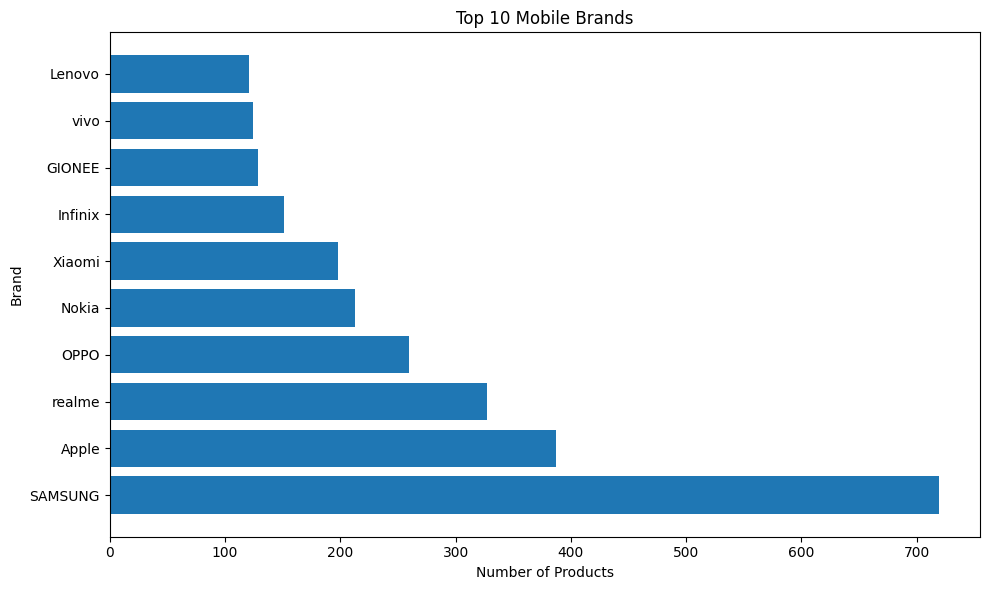

In [46]:
brand_count = df["brand"].fillna("Unknown").value_counts().head(10)

print(brand_count)

plt.figure(figsize=(10, 6))
plt.barh(
    brand_count.index.astype(str),
    brand_count.values
)

plt.title("Top 10 Mobile Brands")
plt.xlabel("Number of Products")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

In [47]:
top_brands = (
    df["brand"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
)

print(top_brands)

brand
SAMSUNG    719
Apple      387
realme     327
OPPO       260
Nokia      213
Xiaomi     198
Infinix    151
GIONEE     129
vivo       124
Lenovo     121
Name: count, dtype: int64


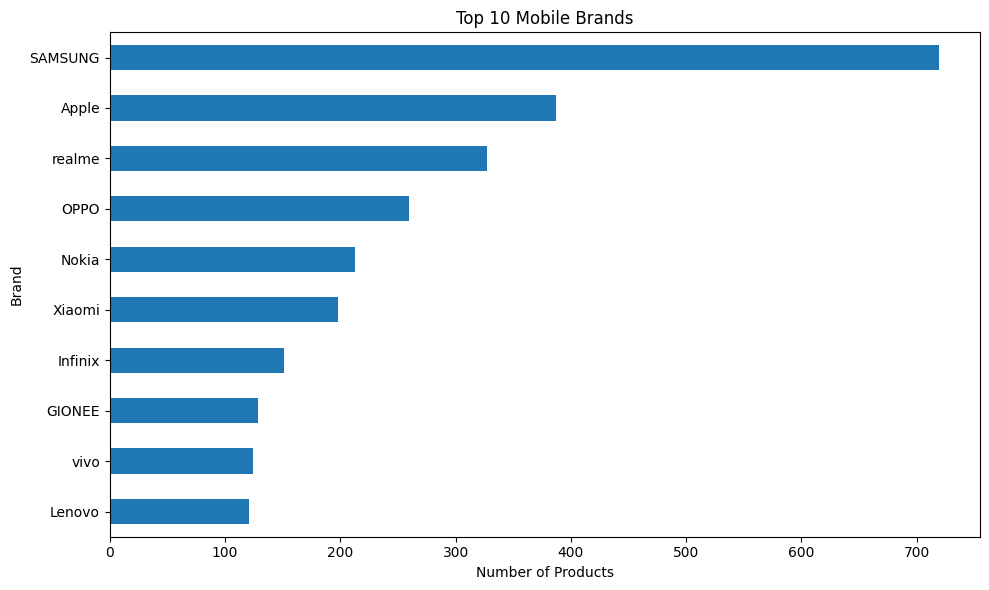

In [48]:
plt.figure(figsize=(10, 6))

top_brands.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Mobile Brands")
plt.xlabel("Number of Products")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

In [49]:
print("Original Price Statistics:")
print(df["original_price"].describe())

print("\nSelling Price Statistics:")
print(df["selling_price"].describe())

Original Price Statistics:
count      3114.000000
mean      28333.473025
std       31525.599889
min        1000.000000
25%       10030.250000
50%       16889.500000
75%       31500.000000
max      189999.000000
Name: original_price, dtype: float64

Selling Price Statistics:
count      3114.000000
mean      26436.625562
std       30066.892622
min        1000.000000
25%        9990.000000
50%       15000.000000
75%       28999.000000
max      179900.000000
Name: selling_price, dtype: float64


In [50]:
top_expensive = df.sort_values(
    "original_price",
    ascending=False
)

top_expensive[
    [
        "brand",
        "model",
        "original_price",
        "selling_price"
    ]
].head(10)

,brand,model,original_price,selling_price
1784,SAMSUNG,Galaxy Fold 2,189999,149999
1685,SAMSUNG,Galaxy Fold 2,189999,149999
1607,SAMSUNG,Galaxy Z Fold3 5G,179999,157999
1596,SAMSUNG,Galaxy Z Fold3 5G,179999,157999
1459,Apple,iPhone 13 Pro Max,179900,179900
3058,Apple,iPhone 13 Pro Max,179900,179900
3057,Apple,iPhone 13 Pro Max,179900,179900
1233,Apple,iPhone 13 Pro Max,179900,179900
1255,Apple,iPhone 13 Pro Max,179900,179900
1351,Apple,iPhone 13 Pro Max,179900,179900


In [51]:
top_discounted = df.sort_values(
    "discount_percentage",
    ascending=False
)

top_discounted[
    [
        "brand",
        "model",
        "original_price",
        "selling_price",
        "discount_percentage"
    ]
].head(10)

,brand,model,original_price,selling_price,discount_percentage
803,GIONEE,Pioneer P3,7996,2350,70.610305
879,GIONEE,Marathon M5 Plus,28099,8499,69.753372
443,ASUS,ROG,83999,26499,68.453196
2389,Motorola,Z2 Force,44999,14999,66.668148
1060,Nokia,8110,8400,3000,64.285714
335,LG,Wing,80000,29999,62.501250
318,LG,Wing,80000,29999,62.501250
903,GIONEE,S6,20924,7999,61.771172
305,LG,G8X,70000,27990,60.014286
366,Google Pixel,Nexus 5X,29990,12000,59.986662


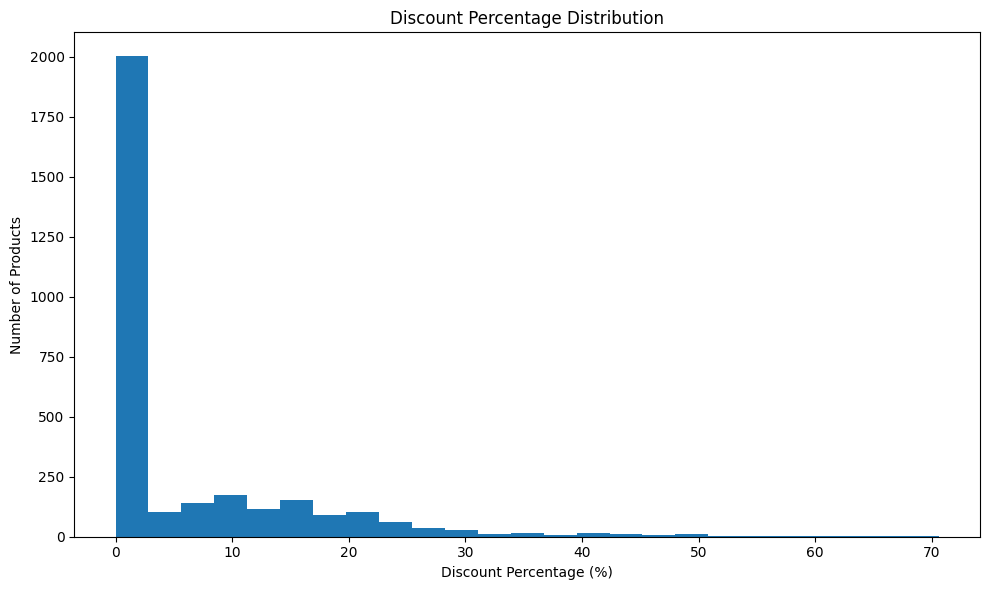

In [52]:
discount_data = df["discount_percentage"].dropna()

discount_data = discount_data[
    (discount_data >= 0) &
    (discount_data <= 100)
]

plt.figure(figsize=(10, 6))

plt.hist(
    discount_data,
    bins=25
)

plt.title("Discount Percentage Distribution")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

In [53]:
df.to_csv(
    "Flipkart_Cleaned_Data.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
